# 10: X5 — DFN with corrected initial protocol (V_init = 2.82V)

## Goal

Replicate v0.1 / X2 / X4 batches with **corrected Phase 2 starting state** to align
sim and experiment Phase 2 starting voltage.

## Why this is necessary

Diagnosis from notebook 09 (X4 finding):
- Experimental MJ1 protocol: 1C dis → CV at 2.5V → 63min rest → measured **U00 = 2.82V**
- Simulation (Chen2020 DFN, same protocol): rest gives V_init = **2.51V** (max 2.5124V at infinite rest)
- **Sim/exp Phase 2 starting voltage differs by 310 mV** — root cause: PyBaMM Chen2020 does NOT model
  Si-graphite hysteresis (Si relaxation takes weeks per literature, not modeled in lumped DFN).

This 310 mV difference in starting V means:
- Sim starts at PyBaMM "true SOC=0%" (V=2.5V)
- Exp starts at "operational SOC=0%" with residual ~1.7% SOC (V=2.82V)
- AC oscillation behavior in early Phase 2 is fundamentally different
- Cases with high κ + low frequency (0.2+0.8C 10τ, 0.3+0.7C 10τ) hit V_min=2.5V cutoff in sim
  but never approach 2.5V in experiment → sim INFEASIBLE on highest-information cases

## Methodology

Replace Phase 0a/0b/1 (discharge + CV + rest) with `set_initial_state(0.01688)`.
SOC=1.688% gives V_init = 2.8206V (bisected, ±1 mV from experiment U00=2.82V).

**New protocol**:
1. `pv.set_initial_state(0.01688)` — uniform internal stoichiometry, V=2.82V
2. Phase 1 = 1 second pseudo-rest (let PyBaMM stabilize transient)
3. Phase 2 = DC+AC CC to 4.2V (same as before)
4. Phase 3 = CV at 4.2V to C/68 (same as before)

**Known limitation**: PyBaMM at SOC=1.688% has uniform Li distribution. Experimental cell at
U00=2.82V has non-uniform internal state (Si-graphite redistribution). Starting V is matched,
but internal concentration gradients are not.

## Three sub-experiments

- **X5-A**: MJ1 frequencies (τ=11.1s) — 31 cases — direct comparison to X2 with corrected V_init
- **X5-B**: Chen-freq R1 (τ_Chen=23.83s) — 31 cases — direct comparison to X4-R1
- **X5-C**: Chen-freq R3 (τ_Chen=19.72s) — 31 cases — direct comparison to X4-R3

Total: 93 cases, ~10 min wall-clock.

## Expected outcomes

This experiment isolates the **starting-state-alignment** variable. Compared to X2/X4:

- **If X5 sign-agreement >> X2/X4**: Phase 2 starting V was the dominant disagreement source.
  Hypotheses 1 & 2 conclusions from X2/X4 were confounded by protocol mismatch.
- **If X5 sign-agreement ≈ X2/X4**: Starting V was not the issue; remaining gap is genuine
  cell-physics or frequency-mismatch.
- **Critical**: 0.2+0.8C 10τ and 0.3+0.7C 10τ should now be **feasible** in sim (V never drops
  below 2.5V if starting from 2.82V). Recovery of these high-AC low-freq cases is by itself a
  portfolio finding.

## Today's deliverable

- Three batch runs (93 cases) saved to JSON+CSV
- 6-way Δt(Q80) comparison: X5-A, X5-B, X5-C, X2, X4-R1, MJ1 exp
- Sign-agreement matrix
- Baseline comparison: which sim/exp gap remains after V_init alignment?
- **No final conclusion yet** — defer to data

In [1]:
# ============================================================
# Cell 2: Imports + run_single_case_DFN_X5
# Key change vs X2/X4: replaces Phase 0a/0b/1 with set_initial_state(0.01688)
# ============================================================
import pybamm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import time
import json
import re

print(f"PyBaMM version: {pybamm.__version__}")
print(f"NumPy version:  {np.__version__}")

# Bisected SOC that gives V_init = 2.8206V on Chen2020 DFN
SOC_INIT_TARGET = 0.01688


def run_single_case_DFN_X5(
    I_DC_Crate: float,
    A_Crate: float,
    f_Hz: float,
    parameter_set: str = "Chen2020",
    T_ambient_C: float = 20.0,
    nominal_capacity_Ah: float = 5.0,
    soc_init: float = SOC_INIT_TARGET,
    pseudo_rest_s: float = 1.0,
    verbose: bool = False,
) -> dict:
    """X5 protocol: set_initial_state(soc_init) instead of CC-CV-rest preconditioning.
    
    Phase 1 = pseudo-rest (1s) to let PyBaMM stabilize transient.
    Phase 2 = DC+AC CC to 4.2V (starts at t≈1s instead of t≈8118.5s)
    Phase 3 = CV at 4.2V to C/68
    """
    
    # Sanitize
    if A_Crate is None or (isinstance(A_Crate, float) and np.isnan(A_Crate)):
        A_Crate = 0.0
    if f_Hz is None or (isinstance(f_Hz, float) and np.isnan(f_Hz)):
        f_Hz = 0.0
    
    I_DC_A = -abs(I_DC_Crate) * nominal_capacity_Ah
    A_A    = A_Crate * nominal_capacity_Ah
    kappa  = (A_Crate / abs(I_DC_Crate)) if abs(I_DC_Crate) > 1e-9 else 0.0
    
    if A_Crate < 1e-9:
        case_id = f"DC{abs(I_DC_Crate):.2f}C_baseline_X5"
    else:
        case_id = f"DC{abs(I_DC_Crate):.2f}C+AC{A_Crate:.2f}C_f{f_Hz:.5f}Hz_X5"
    
    # Phase 2 starts at end of pseudo-rest (~ pseudo_rest_s seconds into simulation)
    t_phase2_start_s = pseudo_rest_s
    
    def dc_ac_current(variables):
        t_absolute = variables["Time [s]"]
        t_relative = t_absolute - t_phase2_start_s
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge",
        description=f"Phase 2: {case_id}",
    )
    
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds",   # Phase 1: pseudo-rest, only 1s
        dcac_step,                              # Phase 2: DC+AC CC
        "Hold at 4.2V until C/68",              # Phase 3: CV
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues(parameter_set)
    pv["Ambient temperature [K]"] = T_ambient_C + 273.15
    pv["Initial temperature [K]"] = T_ambient_C + 273.15
    
    # *** KEY CHANGE: set initial SOC instead of running discharge ***
    pv.set_initial_state(soc_init)
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    
    t_start = time.time()
    try:
        solution = sim.solve()
    except Exception as e:
        return {
            "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
            "kappa": kappa, "wall_clock_s": time.time() - t_start,
            "status": f"FAILED_SOLVE: {type(e).__name__}: {e}",
        }
    wall_clock_s = time.time() - t_start
    
    # X5 protocol expects 3 cycles: rest + dcac + cv
    n_cycles = len(solution.cycles)
    expected_cycles = 3
    
    base_dict = {
        "case_id": case_id, "I_DC_Crate": abs(I_DC_Crate), "A_Crate": A_Crate, "f_Hz": f_Hz,
        "kappa": kappa, "wall_clock_s": wall_clock_s,
        "soc_init": soc_init,
    }
    
    if n_cycles < 2:
        return {**base_dict, "status": f"INFEASIBLE_EARLY: only {n_cycles} cycles"}
    
    if n_cycles < expected_cycles:
        # Phase 2 hit Min V (shouldn't happen with V_init=2.82V, but handle anyway)
        phase2_partial = solution.cycles[1]
        cc_time_partial_s = phase2_partial.t[-1] - phase2_partial.t[0]
        T_max_partial = float(phase2_partial["X-averaged cell temperature [K]"].entries.max() - 273.15)
        V_min_phase2 = float(phase2_partial["Terminal voltage [V]"].entries.min())
        if verbose:
            print(f"  [{case_id}] INFEASIBLE: V_min={V_min_phase2:.3f}V")
        return {
            **base_dict,
            "status": f"INFEASIBLE_MIN_V: V_min={V_min_phase2:.3f}V in Phase 2",
            "CC_time_s_partial": cc_time_partial_s,
            "T_max_charging_C_partial": T_max_partial,
            "V_min_phase2": V_min_phase2,
        }
    
    # Normal case (3 cycles complete)
    phase2 = solution.cycles[1]   # Index 1 (after rest)
    phase3 = solution.cycles[2]   # Index 2
    
    cc_time_s = phase2.t[-1] - phase2.t[0]
    cv_time_s = phase3.t[-1] - phase3.t[0]
    total_time_s = cc_time_s + cv_time_s
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, unique_idx = np.unique(t_chg, return_index=True)
    unique_idx_sorted = np.sort(unique_idx)
    t_chg = t_chg[unique_idx_sorted]
    I_chg = I_chg[unique_idx_sorted]
    t_chg = t_chg - t_chg[0]
    
    Q_net_As = -cumulative_trapezoid(I_chg, t_chg, initial=0)
    Q_net_mAh = Q_net_As / 3600.0 * 1000.0
    Q_final_mAh = float(Q_net_mAh[-1])
    
    dQ = np.diff(Q_net_mAh)
    n_decreases = int(np.sum(dQ < 0))
    pct_decreases = 100.0 * n_decreases / max(len(dQ), 1)
    
    T_max_p2 = float(phase2["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_p3 = float(phase3["X-averaged cell temperature [K]"].entries.max() - 273.15)
    T_max_charging = max(T_max_p2, T_max_p3)
    
    # Initial V at Phase 2 start (sanity check)
    V_init = float(phase2["Voltage [V]"].entries[0])
    
    if verbose:
        print(f"  [{case_id}] V_init={V_init:.4f}V CC={cc_time_s/60:.2f}min "
              f"T_max={T_max_charging:.2f}°C Q={Q_final_mAh:.0f}mAh wall={wall_clock_s:.2f}s")
    
    return {
        **base_dict,
        "V_init_phase2": V_init,
        "CC_time_s": cc_time_s, "CV_time_s": cv_time_s, "total_time_s": total_time_s,
        "CC_time_min": cc_time_s/60, "CV_time_min": cv_time_s/60, "total_time_min": total_time_s/60,
        "Q_net_final_mAh": Q_final_mAh,
        "Q_net_trajectory": Q_net_mAh.tolist(),
        "t_chg": t_chg.tolist(),
        "I_chg": I_chg.tolist(),
        "T_max_charging_C": T_max_charging,
        "n_AC_reversals_steps": n_decreases,
        "pct_AC_reversals": pct_decreases,
        "status": "ok",
    }

print("✓ run_single_case_DFN_X5 defined.")
print(f"  SOC_INIT_TARGET = {SOC_INIT_TARGET:.5f} → V_init ≈ 2.82V (matched to MJ1 experiment U00)")

PyBaMM version: 26.3.1
NumPy version:  2.4.4
✓ run_single_case_DFN_X5 defined.
  SOC_INIT_TARGET = 0.01688 → V_init ≈ 2.82V (matched to MJ1 experiment U00)


In [2]:
# ============================================================
# Cell 3: Sanity check single case before batch
# ============================================================
print("=" * 70)
print("X5 single case validation: DC 0.3C baseline (no AC)")
print("=" * 70)

result_test = run_single_case_DFN_X5(
    I_DC_Crate=0.3, A_Crate=0.0, f_Hz=0.0,
    verbose=True,
)

print(f"\n=== Key metrics ===")
for k in ["V_init_phase2", "CC_time_min", "CV_time_min", "Q_net_final_mAh", 
         "T_max_charging_C", "wall_clock_s"]:
    if k in result_test:
        print(f"  {k}: {result_test[k]:.4f}" if isinstance(result_test[k], float) else f"  {k}: {result_test[k]}")

print(f"\n=== Expected ===")
print(f"  V_init: 2.82V (matched to experiment U00)")
print(f"  CC time: longer than X2's 189min (because Q has to cover more SOC)")
print(f"      X2 starting at SOC=0%: needed ~5126 mAh net charge")
print(f"      X5 starting at SOC=1.688%: needs ~5040 mAh net charge → CC ~165 min?")
print(f"  Wait — Q_net_final accumulates from Phase 2 start, NOT from SOC=0")
print(f"      So Q_net_final should still be ~5040 mAh (from V=2.82V to V=4.2V CV cutoff)")
print(f"      i.e. less than 5126 mAh because we skip the bottom 1.688%")

X5 single case validation: DC 0.3C baseline (no AC)
  [DC0.30C_baseline_X5] V_init=2.9095V CC=185.72min T_max=21.90°C Q=5042mAh wall=0.58s

=== Key metrics ===
  V_init_phase2: 2.9095
  CC_time_min: 185.7166
  CV_time_min: 55.2533
  Q_net_final_mAh: 5042.0788
  T_max_charging_C: 21.8997
  wall_clock_s: 0.5799

=== Expected ===
  V_init: 2.82V (matched to experiment U00)
  CC time: longer than X2's 189min (because Q has to cover more SOC)
      X2 starting at SOC=0%: needed ~5126 mAh net charge
      X5 starting at SOC=1.688%: needs ~5040 mAh net charge → CC ~165 min?
  Wait — Q_net_final accumulates from Phase 2 start, NOT from SOC=0
      So Q_net_final should still be ~5040 mAh (from V=2.82V to V=4.2V CV cutoff)
      i.e. less than 5126 mAh because we skip the bottom 1.688%


In [3]:
# ============================================================
# Cell 4: X5-A batch — DFN + V_init=2.82V + MJ1 frequencies (τ=11.1s)
# Direct comparison to X2 with corrected initial protocol
# ============================================================

# Load v0.1 cases (precise frequencies from JSON)
with open("../data/results_day6_batch_scan.json", "r") as f:
    v01_json = json.load(f)

# Parse precise (DC, AC, f) from case_id strings
cases_X5A = []
for entry in v01_json:
    cid = entry["case_id"]
    if "_baseline" in cid:
        m = re.match(r"DC([\d.]+)C_baseline", cid)
        if m:
            cases_X5A.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)), "A_C": 0.0, "f_Hz": 0.0,
                "tau_label": "baseline",
            })
    else:
        m = re.match(r"DC([\d.]+)C\+AC([\d.]+)C_f([\d.]+)Hz", cid)
        if m:
            cases_X5A.append({
                "condition": entry.get("condition_label", cid),
                "I_DC_C": float(m.group(1)),
                "A_C": float(m.group(2)),
                "f_Hz": float(m.group(3)),
                "tau_label": entry.get("condition_label", "").split()[-1],
            })

# Add the v0.1 missing infeasible case
cases_X5A.append({
    "condition": "0.2+0.8C 10τ",
    "I_DC_C": 0.2, "A_C": 0.8, "f_Hz": 0.00143,
    "tau_label": "10τ",
})

print(f"X5-A: {len(cases_X5A)} cases (DFN + V_init=2.82V + MJ1-freq)")
print("=" * 70)

x5A_results = []
batch_t_start = time.time()
n_ok, n_infeas, n_fail = 0, 0, 0

for i, case in enumerate(cases_X5A):
    cond = case["condition"]
    DC = case["I_DC_C"]
    A = case["A_C"]
    f = case["f_Hz"]
    
    print(f"[{i+1:2d}/{len(cases_X5A)}] {cond:25s} (DC={DC:.2f}, AC={A:.2f}, f={f:.5f}Hz)... ",
          end="", flush=True)
    
    r = run_single_case_DFN_X5(
        I_DC_Crate=DC, A_Crate=A, f_Hz=f,
        parameter_set="Chen2020", T_ambient_C=20.0,
        nominal_capacity_Ah=5.0, soc_init=SOC_INIT_TARGET,
        verbose=False,
    )
    r["condition"] = cond
    r["tau_label"] = case["tau_label"]
    r["batch"] = "X5-A"
    x5A_results.append(r)
    
    if r["status"] == "ok":
        n_ok += 1
        print(f"✓ V0={r['V_init_phase2']:.3f}V CC={r['CC_time_min']:.1f}m "
              f"T={r['T_max_charging_C']:.1f}°C Q={r['Q_net_final_mAh']:.0f}mAh ({r['wall_clock_s']:.1f}s)")
    elif "INFEASIBLE" in r["status"]:
        n_infeas += 1
        print(f"⊘ INFEASIBLE ({r['wall_clock_s']:.1f}s)")
    else:
        n_fail += 1
        print(f"✗ FAILED: {r['status']}")

batch_total = time.time() - batch_t_start
print("\n" + "=" * 70)
print(f"X5-A batch complete: {n_ok} ok, {n_infeas} infeasible, {n_fail} failed")
print(f"Total wall-clock: {batch_total:.1f}s")
print("=" * 70)

# Save
df_X5A = pd.DataFrame(x5A_results)
df_X5A.drop(columns=[c for c in ["Q_net_trajectory","t_chg","I_chg"] if c in df_X5A.columns]).to_csv(
    "../data/results_day8_x5A_dfn_corrected_mj1freq.csv", index=False
)
with open("../data/results_day8_x5A_dfn_corrected_mj1freq.json", "w") as f:
    json.dump(x5A_results, f, default=str)
print(f"\nSaved: ../data/results_day8_x5A_dfn_corrected_mj1freq.csv + .json")

X5-A: 31 cases (DFN + V_init=2.82V + MJ1-freq)
[ 1/31] 0.1+0.9C 1τ               (DC=0.10, AC=0.90, f=0.01430Hz)... ✓ V0=2.858V CC=489.3m T=26.4°C Q=5034mAh (7.2s)
[ 2/31] 0.1+0.2C 1τ               (DC=0.10, AC=0.20, f=0.01430Hz)... ✓ V0=2.858V CC=573.1m T=20.7°C Q=5040mAh (2.2s)
[ 3/31] 0.2+0.3C 1τ               (DC=0.20, AC=0.30, f=0.01430Hz)... ✓ V0=2.887V CC=272.4m T=21.9°C Q=5041mAh (1.9s)
[ 4/31] 0.2+0.3C 10τ              (DC=0.20, AC=0.30, f=0.00143Hz)... ✓ V0=2.887V CC=265.0m T=22.3°C Q=5043mAh (0.7s)
[ 5/31] 0.2+0.3C 34.8τ            (DC=0.20, AC=0.30, f=0.00041Hz)... ✓ V0=2.887V CC=272.7m T=23.1°C Q=5043mAh (0.6s)
[ 6/31] 0.2+0.8C 0.1τ             (DC=0.20, AC=0.80, f=0.14300Hz)... ✓ V0=2.887V CC=243.9m T=25.2°C Q=5031mAh (38.0s)
[ 7/31] 0.2+0.8C 1τ               (DC=0.20, AC=0.80, f=0.01430Hz)... ✓ V0=2.887V CC=239.8m T=25.4°C Q=5039mAh (3.6s)
[ 8/31] 0.2+0.8C 10τ              (DC=0.20, AC=0.80, f=0.00143Hz)... ✓ V0=2.887V CC=230.2m T=27.1°C Q=5043mAh (0.9s)
[ 9/31] 0.3+0.7C

In [4]:
# ============================================================
# Cell 5: X5-B + X5-C batches — Chen-freq R1 (τ=23.83s) + R3 (τ=19.72s)
# Total: 62 cases (R1 + R3) ≈ 4 min wall-clock
# ============================================================

TAU_MJ1 = 11.1
TAU_CHEN_R1 = 23.83
TAU_CHEN_R3 = 19.72
RESCALE_R1 = TAU_MJ1 / TAU_CHEN_R1   # 0.4658
RESCALE_R3 = TAU_MJ1 / TAU_CHEN_R3   # 0.5629

# Build Chen-freq cases for both rounds
def build_cases_with_rescale(rescale_factor, round_label, tau_chen):
    cases = []
    for entry in v01_json:
        cid = entry["case_id"]
        if "_baseline" in cid:
            m = re.match(r"DC([\d.]+)C_baseline", cid)
            if m:
                cases.append({
                    "condition": entry.get("condition_label", cid),
                    "I_DC_C": float(m.group(1)), "A_C": 0.0,
                    "f_Hz_v01": 0.0, "f_Hz_X5": 0.0,
                    "tau_label": "baseline",
                    "round": round_label, "tau_Chen_s": tau_chen,
                })
        else:
            m = re.match(r"DC([\d.]+)C\+AC([\d.]+)C_f([\d.]+)Hz", cid)
            if m:
                f_v01 = float(m.group(3))
                cases.append({
                    "condition": entry.get("condition_label", cid),
                    "I_DC_C": float(m.group(1)),
                    "A_C": float(m.group(2)),
                    "f_Hz_v01": f_v01,
                    "f_Hz_X5": f_v01 * rescale_factor,
                    "tau_label": entry.get("condition_label", "").split()[-1],
                    "round": round_label, "tau_Chen_s": tau_chen,
                })
    # Add infeasible case
    cases.append({
        "condition": "0.2+0.8C 10τ",
        "I_DC_C": 0.2, "A_C": 0.8,
        "f_Hz_v01": 0.00143, "f_Hz_X5": 0.00143 * rescale_factor,
        "tau_label": "10τ",
        "round": round_label, "tau_Chen_s": tau_chen,
    })
    return cases

cases_X5B = build_cases_with_rescale(RESCALE_R1, "X5-B", TAU_CHEN_R1)
cases_X5C = build_cases_with_rescale(RESCALE_R3, "X5-C", TAU_CHEN_R3)
cases_X5_BC = cases_X5B + cases_X5C

print(f"X5-B + X5-C: {len(cases_X5_BC)} total cases (31 + 31)")
print(f"  X5-B: τ_Chen={TAU_CHEN_R1}s, rescale={RESCALE_R1:.4f}")
print(f"  X5-C: τ_Chen={TAU_CHEN_R3}s, rescale={RESCALE_R3:.4f}")
print("=" * 70)

x5_BC_results = []
batch_t_start = time.time()
n_ok = {"X5-B": 0, "X5-C": 0}
n_infeas = {"X5-B": 0, "X5-C": 0}
n_fail = {"X5-B": 0, "X5-C": 0}

for i, case in enumerate(cases_X5_BC):
    rnd = case["round"]
    cond = case["condition"]
    DC = case["I_DC_C"]
    A = case["A_C"]
    f = case["f_Hz_X5"]
    
    print(f"[{i+1:2d}/{len(cases_X5_BC)}] [{rnd}] {cond:20s} (DC={DC:.2f}, AC={A:.2f}, f={f:.5f}Hz)... ",
          end="", flush=True)
    
    r = run_single_case_DFN_X5(
        I_DC_Crate=DC, A_Crate=A, f_Hz=f,
        parameter_set="Chen2020", T_ambient_C=20.0,
        nominal_capacity_Ah=5.0, soc_init=SOC_INIT_TARGET,
        verbose=False,
    )
    r["condition"] = cond
    r["tau_label"] = case["tau_label"]
    r["batch"] = rnd
    r["tau_Chen_s"] = case["tau_Chen_s"]
    r["f_Hz_v01"] = case["f_Hz_v01"]
    x5_BC_results.append(r)
    
    if r["status"] == "ok":
        n_ok[rnd] += 1
        print(f"✓ V0={r['V_init_phase2']:.3f}V CC={r['CC_time_min']:.1f}m "
              f"T={r['T_max_charging_C']:.1f}°C Q={r['Q_net_final_mAh']:.0f}mAh ({r['wall_clock_s']:.1f}s)")
    elif "INFEASIBLE" in r["status"]:
        n_infeas[rnd] += 1
        print(f"⊘ INFEASIBLE ({r['wall_clock_s']:.1f}s)")
    else:
        n_fail[rnd] += 1
        print(f"✗ FAILED: {r['status']}")

batch_total = time.time() - batch_t_start
print("\n" + "=" * 70)
print(f"X5-B+C batch complete:")
print(f"  X5-B (τ=23.83s): {n_ok['X5-B']} ok, {n_infeas['X5-B']} infeasible, {n_fail['X5-B']} failed")
print(f"  X5-C (τ=19.72s): {n_ok['X5-C']} ok, {n_infeas['X5-C']} infeasible, {n_fail['X5-C']} failed")
print(f"Total wall-clock: {batch_total:.1f}s")
print("=" * 70)

# Save
df_X5_BC = pd.DataFrame(x5_BC_results)
df_X5_BC.drop(columns=[c for c in ["Q_net_trajectory","t_chg","I_chg"] if c in df_X5_BC.columns]).to_csv(
    "../data/results_day8_x5BC_dfn_corrected_chenfreq.csv", index=False
)
with open("../data/results_day8_x5BC_dfn_corrected_chenfreq.json", "w") as f:
    json.dump(x5_BC_results, f, default=str)
print(f"\nSaved: ../data/results_day8_x5BC_dfn_corrected_chenfreq.csv + .json")

X5-B + X5-C: 62 total cases (31 + 31)
  X5-B: τ_Chen=23.83s, rescale=0.4658
  X5-C: τ_Chen=19.72s, rescale=0.5629
[ 1/62] [X5-B] 0.1+0.9C 1τ          (DC=0.10, AC=0.90, f=0.00666Hz)... ✓ V0=2.858V CC=477.4m T=26.8°C Q=5044mAh (3.4s)
[ 2/62] [X5-B] 0.1+0.2C 1τ          (DC=0.10, AC=0.20, f=0.00666Hz)... ✓ V0=2.858V CC=572.3m T=20.8°C Q=5041mAh (1.2s)
[ 3/62] [X5-B] 0.2+0.3C 1τ          (DC=0.20, AC=0.30, f=0.00666Hz)... ✓ V0=2.887V CC=269.6m T=22.0°C Q=5043mAh (1.2s)
[ 4/62] [X5-B] 0.2+0.3C 10τ         (DC=0.20, AC=0.30, f=0.00067Hz)... ✓ V0=2.887V CC=268.1m T=22.6°C Q=5041mAh (0.6s)
[ 5/62] [X5-B] 0.2+0.3C 34.8τ       (DC=0.20, AC=0.30, f=0.00019Hz)... ✓ V0=2.887V CC=313.3m T=23.8°C Q=5044mAh (0.6s)
[ 6/62] [X5-B] 0.2+0.8C 0.1τ        (DC=0.20, AC=0.80, f=0.06661Hz)... ✓ V0=2.887V CC=243.4m T=25.2°C Q=5031mAh (17.0s)
[ 7/62] [X5-B] 0.2+0.8C 1τ          (DC=0.20, AC=0.80, f=0.00666Hz)... ✓ V0=2.887V CC=234.7m T=25.7°C Q=5042mAh (1.9s)
[ 8/62] [X5-B] 0.2+0.8C 10τ         (DC=0.20, AC=0.8

2026-04-27 13:34:32.540 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00067Hz_X5'. The returned solution only contains up to step 1 of cycle 2. 


⊘ INFEASIBLE (0.5s)
[ 9/62] [X5-B] 0.3+0.7C 0.1τ        (DC=0.30, AC=0.70, f=0.06661Hz)... ✓ V0=2.910V CC=159.1m T=25.1°C Q=5036mAh (10.0s)
[10/62] [X5-B] 0.3+0.7C 1τ          (DC=0.30, AC=0.70, f=0.00666Hz)... ✓ V0=2.910V CC=154.5m T=25.6°C Q=5041mAh (1.4s)
[11/62] [X5-B] 0.3+0.7C 10τ         (DC=0.30, AC=0.70, f=0.00067Hz)... ✓ V0=2.910V CC=166.4m T=27.8°C Q=5044mAh (0.7s)
[12/62] [X5-B] 0.3+0.4C 0.1τ        (DC=0.30, AC=0.40, f=0.06661Hz)... ✓ V0=2.910V CC=166.6m T=23.5°C Q=5041mAh (7.4s)
[13/62] [X5-B] 0.3+0.4C 1τ          (DC=0.30, AC=0.40, f=0.00666Hz)... ✓ V0=2.910V CC=164.4m T=23.7°C Q=5043mAh (1.0s)
[14/62] [X5-B] 0.3+0.4C 10τ         (DC=0.30, AC=0.40, f=0.00067Hz)... ✓ V0=2.910V CC=167.1m T=24.4°C Q=5045mAh (0.6s)
[15/62] [X5-B] 0.4+0.6C 0.5τ        (DC=0.40, AC=0.60, f=0.01332Hz)... ✓ V0=2.927V CC=116.0m T=25.5°C Q=5041mAh (1.7s)
[16/62] [X5-B] 0.4+0.5C 1.67τ       (DC=0.40, AC=0.50, f=0.00401Hz)... ✓ V0=2.927V CC=115.4m T=25.4°C Q=5044mAh (0.8s)
[17/62] [X5-B] 0.4+0.6C 1.6

2026-04-27 13:35:07.709 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00067Hz_X5'. The returned solution only contains up to step 1 of cycle 2. 


⊘ INFEASIBLE (0.4s)
[32/62] [X5-C] 0.1+0.9C 1τ          (DC=0.10, AC=0.90, f=0.00805Hz)... ✓ V0=2.858V CC=482.0m T=26.6°C Q=5039mAh (4.2s)
[33/62] [X5-C] 0.1+0.2C 1τ          (DC=0.10, AC=0.20, f=0.00805Hz)... ✓ V0=2.858V CC=571.0m T=20.8°C Q=5040mAh (1.4s)
[34/62] [X5-C] 0.2+0.3C 1τ          (DC=0.20, AC=0.30, f=0.00805Hz)... ✓ V0=2.887V CC=270.7m T=21.9°C Q=5043mAh (1.2s)
[35/62] [X5-C] 0.2+0.3C 10τ         (DC=0.20, AC=0.30, f=0.00080Hz)... ✓ V0=2.887V CC=264.2m T=22.5°C Q=5043mAh (0.7s)
[36/62] [X5-C] 0.2+0.3C 34.8τ       (DC=0.20, AC=0.30, f=0.00023Hz)... ✓ V0=2.887V CC=272.8m T=23.7°C Q=5042mAh (0.6s)
[37/62] [X5-C] 0.2+0.8C 0.1τ        (DC=0.20, AC=0.80, f=0.08049Hz)... ✓ V0=2.887V CC=243.5m T=25.2°C Q=5030mAh (20.7s)
[38/62] [X5-C] 0.2+0.8C 1τ          (DC=0.20, AC=0.80, f=0.00805Hz)... ✓ V0=2.887V CC=235.6m T=25.6°C Q=5040mAh (2.1s)
[39/62] [X5-C] 0.2+0.8C 10τ         (DC=0.20, AC=0.80, f=0.00080Hz)... 

2026-04-27 13:35:39.689 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00080Hz_X5'. The returned solution only contains up to step 1 of cycle 2. 


⊘ INFEASIBLE (0.4s)
[40/62] [X5-C] 0.3+0.7C 0.1τ        (DC=0.30, AC=0.70, f=0.08049Hz)... ✓ V0=2.910V CC=159.2m T=25.1°C Q=5035mAh (12.1s)
[41/62] [X5-C] 0.3+0.7C 1τ          (DC=0.30, AC=0.70, f=0.00805Hz)... ✓ V0=2.910V CC=154.8m T=25.5°C Q=5041mAh (1.5s)
[42/62] [X5-C] 0.3+0.7C 10τ         (DC=0.30, AC=0.70, f=0.00080Hz)... ✓ V0=2.910V CC=159.2m T=27.4°C Q=5043mAh (0.8s)
[43/62] [X5-C] 0.3+0.4C 0.1τ        (DC=0.30, AC=0.40, f=0.08049Hz)... ✓ V0=2.910V CC=166.8m T=23.5°C Q=5043mAh (8.9s)
[44/62] [X5-C] 0.3+0.4C 1τ          (DC=0.30, AC=0.40, f=0.00805Hz)... ✓ V0=2.910V CC=163.1m T=23.8°C Q=5042mAh (1.3s)
[45/62] [X5-C] 0.3+0.4C 10τ         (DC=0.30, AC=0.40, f=0.00080Hz)... ✓ V0=2.910V CC=160.5m T=24.4°C Q=5044mAh (0.6s)
[46/62] [X5-C] 0.4+0.6C 0.5τ        (DC=0.40, AC=0.60, f=0.01610Hz)... ✓ V0=2.927V CC=115.7m T=25.5°C Q=5040mAh (1.9s)
[47/62] [X5-C] 0.4+0.5C 1.67τ       (DC=0.40, AC=0.50, f=0.00484Hz)... ✓ V0=2.927V CC=116.1m T=25.3°C Q=5042mAh (1.0s)
[48/62] [X5-C] 0.4+0.6C 1.6

2026-04-27 13:36:19.507 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Phase 2: DC0.20C+AC0.80C_f0.00080Hz_X5'. The returned solution only contains up to step 1 of cycle 2. 


⊘ INFEASIBLE (0.5s)

X5-B+C batch complete:
  X5-B (τ=23.83s): 29 ok, 2 infeasible, 0 failed
  X5-C (τ=19.72s): 29 ok, 2 infeasible, 0 failed
Total wall-clock: 134.4s

Saved: ../data/results_day8_x5BC_dfn_corrected_chenfreq.csv + .json


In [5]:
# ============================================================
# Cell 6: Core 4-way Δt(Q80) — MJ1 frequency, sim/exp protocol alignment
# X5-A (V_init=2.82V) vs X2 (V_init=2.51V) vs v0.1 SPMe (V_init=2.51V) vs MJ1 exp
# All same frequency family (MJ1 τ=11.1s), only sim protocol differs.
# ============================================================

# Load all data
with open("../data/results_day8_x5A_dfn_corrected_mj1freq.json", "r") as f:
    x5A_results_loaded = json.load(f)
with open("../data/results_day8_x2_dfn_mj1freq_v2.json", "r") as f:
    x2_results_loaded = json.load(f)
with open("../data/results_day6_batch_scan.json", "r") as f:
    v01_json_loaded = json.load(f)
df_v01_csv = pd.read_csv("../data/results_day6_summary.csv")

# Coerce JSON-loaded data (lists may be strings)
def coerce(results):
    for r in results:
        for k in ["Q_net_trajectory", "t_chg", "I_chg"]:
            if k in r and isinstance(r[k], str):
                try: r[k] = json.loads(r[k])
                except: pass
        for k in ["A_Crate", "I_DC_Crate", "f_Hz"]:
            if k in r and isinstance(r[k], str):
                try: r[k] = float(r[k])
                except: pass
    return results

x5A_results_loaded = coerce(x5A_results_loaded)
x2_results_loaded = coerce(x2_results_loaded)
# v01_json_loaded is fresh from disk — already proper types

# Δt(Q80) interpolated computation
def compute_dt_at_Q_interp(t_chg, Q_net_mAh, t_chg_baseline, Q_net_baseline_mAh, Q_target_mAh):
    def first_passage_interp(t, Q):
        t = np.asarray(t, dtype=float)
        Q = np.asarray(Q, dtype=float)
        idx = np.where(Q >= Q_target_mAh)[0]
        if len(idx) == 0:
            return np.nan
        i = int(idx[0])
        if i == 0:
            return float(t[0])
        Q_lo, Q_hi = Q[i-1], Q[i]
        t_lo, t_hi = t[i-1], t[i]
        if Q_hi == Q_lo:
            return float(t_lo)
        frac = (Q_target_mAh - Q_lo) / (Q_hi - Q_lo)
        return float(t_lo + frac * (t_hi - t_lo))
    
    t_proto = first_passage_interp(t_chg, Q_net_mAh)
    t_base = first_passage_interp(t_chg_baseline, Q_net_baseline_mAh)
    if np.isnan(t_proto) or np.isnan(t_base):
        return np.nan
    return (t_base - t_proto) / 60.0   # minutes

# CRITICAL: Q80 target depends on the cell capacity / starting SOC 
# X5-A starts at SOC=1.688% (Q_net=0 at start), reaches Q≈5042 mAh at Q80 inflection
# The Q80 target needs to be relative to TOTAL capacity, not Q_net trajectory length
# Total nominal: 5126 mAh (Chen2020 5Ah at 100% SOC)
# 80% of 5126 = 4101 mAh = Q80 in absolute SOC terms
# But X5 Q_net starts from ~0 at SOC=1.688%, so Q80 in X5-trajectory-terms = 4101 - 86.5 = 4014 mAh
# 
# Actually no — Q_net for X5 is "charge accumulated since Phase 2 start", same as X2.
# But the CELL state is different at Phase 2 start (SOC=1.688% vs SOC=0% for X2).
# 
# To compare Δt at the SAME CELL STATE (=80% SOC absolute):
#   X2:  Q80 = 0.80 * 5126 = 4101 mAh  (SOC 0% → 80%)
#   X5:  Q80 = 0.80 * 5126 - 86.5 = 4014 mAh  (SOC 1.688% → 80%)
# Or interpret "Q80" as "AC accelerates to reach 80% of Phase 2 cumulative":
#   Both: Q80 = 0.80 * Q_final ≈ 4034 mAh (X5) vs 4101 mAh (X2)
#
# CORRECT INTERPRETATION: Q80 is "80% of the way to fully charged"
# Sim: SOC at Phase 2 start ≠ 0% in X5 → Q_net target must adjust
# v0.1/X2 had Q_net_final ≈ 5126 mAh, used Q80 = 4101 mAh
# X5-A has Q_net_final ≈ 5042 mAh (skipped 86.5 mAh = SOC 0 → 1.688%)
# So X5 Q80 should target: 4101 - 86.5 = 4014.5 mAh (same absolute SOC=80%)

Q80_TARGET_X2 = 0.80 * 5126.0       # 4101 mAh (same absolute Q80 as v0.1)
Q80_TARGET_X5 = 4101.0 - 86.5        # 4014.5 mAh (subtract skipped SOC)

print(f"Q80 targets:")
print(f"  v0.1, X2 (V_init=2.51V): {Q80_TARGET_X2:.1f} mAh (Q_net since Phase 2 start)")
print(f"  X5-A (V_init=2.82V):     {Q80_TARGET_X5:.1f} mAh (adjusted for SOC=1.688% start)")
print(f"  Both target absolute SOC = 80% on the cell")

# Build baselines: keyed by DC C-rate
def build_baselines(results):
    bl = {}
    for r in results:
        if r["A_Crate"] < 1e-9 and r.get("status") == "ok":
            bl[round(float(r["I_DC_Crate"]), 2)] = (
                np.array(r["t_chg"]), np.array(r["Q_net_trajectory"])
            )
    return bl

bl_x5A = build_baselines(x5A_results_loaded)
bl_x2 = build_baselines(x2_results_loaded)
bl_v01 = build_baselines(v01_json_loaded)

print(f"\nBaselines: x5A={sorted(bl_x5A.keys())} x2={sorted(bl_x2.keys())} v01={sorted(bl_v01.keys())}")

# Compute Δt(Q80) for each non-baseline case keyed by (DC, AC, f_Hz)
def compute_dt_dict(results, baselines, Q80_target):
    out = {}
    for r in results:
        if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
            continue
        DC = round(float(r["I_DC_Crate"]), 2)
        AC = round(float(r["A_Crate"]), 2)
        f = round(float(r["f_Hz"]), 5)
        if DC not in baselines:
            continue
        t_base, Q_base = baselines[DC]
        dt = compute_dt_at_Q_interp(
            np.array(r["t_chg"]), np.array(r["Q_net_trajectory"]),
            t_base, Q_base, Q80_target,
        )
        out[(DC, AC, f)] = dt
    return out

dt_x5A = compute_dt_dict(x5A_results_loaded, bl_x5A, Q80_TARGET_X5)
dt_x2  = compute_dt_dict(x2_results_loaded, bl_x2, Q80_TARGET_X2)
dt_v01 = compute_dt_dict(v01_json_loaded, bl_v01, Q80_TARGET_X2)

# Build comparison anchored on X5-A keys
def sign(x):
    if np.isnan(x): return None
    if x > 0.05: return "+"
    if x < -0.05: return "-"
    return "0"

rows4 = []
for r in x5A_results_loaded:
    if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
        continue
    DC = round(float(r["I_DC_Crate"]), 2)
    AC = round(float(r["A_Crate"]), 2)
    f = round(float(r["f_Hz"]), 5)
    cond = r["condition"]
    tau_lbl = r.get("tau_label", "?")
    
    key = (DC, AC, f)
    dt_x5A_v = dt_x5A.get(key, np.nan)
    dt_x2_v = dt_x2.get(key, np.nan)
    dt_v01_v = dt_v01.get(key, np.nan)
    
    # Exp Δt from CSV
    dt_exp_v = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp_v = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    s_X5A, s_X2, s_v01, s_exp = sign(dt_x5A_v), sign(dt_x2_v), sign(dt_v01_v), sign(dt_exp_v)
    
    rows4.append({
        "condition": cond,
        "DC": DC, "AC": AC, "f_Hz": f, "kappa": AC/DC, "tau_label": tau_lbl,
        "dt_X5A": dt_x5A_v, "dt_X2": dt_x2_v, "dt_v01": dt_v01_v, "dt_exp": dt_exp_v,
        "s_X5A": s_X5A, "s_X2": s_X2, "s_v01": s_v01, "s_exp": s_exp,
        "X5A_vs_exp": (s_X5A == s_exp) if (s_X5A and s_exp) else None,
        "X2_vs_exp":  (s_X2 == s_exp)  if (s_X2 and s_exp)  else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "X5A_vs_X2":  (s_X5A == s_X2)  if (s_X5A and s_X2)  else None,
    })

df4 = pd.DataFrame(rows4)
display_cols = ["condition", "kappa", "tau_label",
                "dt_X5A", "dt_X2", "dt_v01", "dt_exp",
                "s_X5A", "s_X2", "s_v01", "s_exp",
                "X5A_vs_exp", "X2_vs_exp", "v01_vs_exp", "X5A_vs_X2"]

print(f"\n=== Core 4-way Δt(Q80) — all MJ1 freq, sim protocol differs ===\n")
with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 280, 'display.max_columns', 30):
    print(df4[display_cols].to_string(index=False))

print("\n" + "=" * 70)
print("Sign-agreement statistics — V_init alignment effect")
print("=" * 70)

def stats(col, label):
    valid = df4[col].dropna()
    if len(valid) == 0:
        return f"  {label}: no valid"
    n_agree = int(valid.sum())
    n_valid = len(valid)
    return f"  {label}: {n_agree}/{n_valid} ({100*n_agree/n_valid:.1f}%)"

print(stats("v01_vs_exp", "v0.1 (SPMe + V_init=2.51V) vs exp"))
print(stats("X2_vs_exp",  "X2   (DFN  + V_init=2.51V) vs exp"))
print(stats("X5A_vs_exp", "X5-A (DFN  + V_init=2.82V) vs exp  ← protocol-aligned"))
print()
print(stats("X5A_vs_X2",  "X5-A vs X2 (V_init alignment effect, same model & freq)"))

# Sign distribution check
print("\n=== Sign distribution per source ===")
for src, col in [("v0.1", "s_v01"), ("X2", "s_X2"), ("X5-A", "s_X5A"), ("exp", "s_exp")]:
    counts = df4[col].value_counts(dropna=False).to_dict()
    print(f"  {src:10s}: {counts}")

df4.to_csv("../data/results_day8_x5_4way_dt_Q80.csv", index=False)
print(f"\nSaved: ../data/results_day8_x5_4way_dt_Q80.csv")

Q80 targets:
  v0.1, X2 (V_init=2.51V): 4100.8 mAh (Q_net since Phase 2 start)
  X5-A (V_init=2.82V):     4014.5 mAh (adjusted for SOC=1.688% start)
  Both target absolute SOC = 80% on the cell

Baselines: x5A=[0.1, 0.2, 0.3, 0.4, 0.5, 0.9] x2=[0.1, 0.2, 0.3, 0.4, 0.5, 0.9] v01=[0.1, 0.2, 0.3, 0.4, 0.5, 0.9]

=== Core 4-way Δt(Q80) — all MJ1 freq, sim protocol differs ===

     condition  kappa tau_label  dt_X5A  dt_X2  dt_v01  dt_exp s_X5A s_X2 s_v01 s_exp  X5A_vs_exp X2_vs_exp v01_vs_exp X5A_vs_X2
   0.1+0.9C 1τ +9.000        1τ  -1.764 +0.258  -0.737  +2.880     -    +     -     +       False      True      False     False
   0.1+0.2C 1τ +2.000        1τ  -0.477 -0.528  -0.534  +0.590     -    -     -     +       False     False      False      True
   0.2+0.3C 1τ +1.500        1τ  -0.210 -0.577  -0.536  +0.170     -    -     -     +       False     False      False      True
  0.2+0.3C 10τ +1.500       10τ  -1.712 -5.296  -5.315  +5.050     -    -     -     +       False     False 

In [6]:
# Cell 6b: Re-compute X5-A Δt(Q80) with Q80 = 4101 mAh (matching v0.1/X2 convention)
# Reason: Δt(Q80) per thesis (a) definition uses Q_net=4101 mAh regardless of starting SOC

Q80_UNIFIED = 4101.0   # 80% × 5126 mAh nominal Chen2020

# Recompute X5-A dt with unified target
dt_x5A_v2 = compute_dt_dict(x5A_results_loaded, bl_x5A, Q80_UNIFIED)

# Rebuild df4 with corrected X5-A
rows4_v2 = []
for r in x5A_results_loaded:
    if r["A_Crate"] < 1e-9 or r.get("status") != "ok":
        continue
    DC = round(float(r["I_DC_Crate"]), 2)
    AC = round(float(r["A_Crate"]), 2)
    f = round(float(r["f_Hz"]), 5)
    cond = r["condition"]
    tau_lbl = r.get("tau_label", "?")
    
    key = (DC, AC, f)
    dt_x5A_v = dt_x5A_v2.get(key, np.nan)
    dt_x2_v = dt_x2.get(key, np.nan)
    dt_v01_v = dt_v01.get(key, np.nan)
    
    dt_exp_v = np.nan
    csv_match = df_v01_csv[df_v01_csv["condition"] == cond]
    if len(csv_match) > 0 and pd.notna(csv_match["exp_Δt_Q80"].iloc[0]):
        dt_exp_v = float(csv_match["exp_Δt_Q80"].iloc[0])
    
    s_X5A, s_X2, s_v01, s_exp = sign(dt_x5A_v), sign(dt_x2_v), sign(dt_v01_v), sign(dt_exp_v)
    
    rows4_v2.append({
        "condition": cond,
        "DC": DC, "AC": AC, "f_Hz": f, "kappa": AC/DC, "tau_label": tau_lbl,
        "dt_X5A": dt_x5A_v, "dt_X2": dt_x2_v, "dt_v01": dt_v01_v, "dt_exp": dt_exp_v,
        "s_X5A": s_X5A, "s_X2": s_X2, "s_v01": s_v01, "s_exp": s_exp,
        "X5A_vs_exp": (s_X5A == s_exp) if (s_X5A and s_exp) else None,
        "X2_vs_exp":  (s_X2 == s_exp)  if (s_X2 and s_exp)  else None,
        "v01_vs_exp": (s_v01 == s_exp) if (s_v01 and s_exp) else None,
        "X5A_vs_X2":  (s_X5A == s_X2)  if (s_X5A and s_X2)  else None,
    })

df4_v2 = pd.DataFrame(rows4_v2)

display_cols = ["condition", "kappa", "tau_label",
                "dt_X5A", "dt_X2", "dt_v01", "dt_exp",
                "s_X5A", "s_X2", "s_v01", "s_exp",
                "X5A_vs_exp", "X2_vs_exp", "v01_vs_exp", "X5A_vs_X2"]

print(f"=== Core 4-way Δt(Q80) — UNIFIED Q80=4101 mAh ===\n")
with pd.option_context('display.float_format', '{:+.3f}'.format,
                        'display.width', 280, 'display.max_columns', 30):
    print(df4_v2[display_cols].to_string(index=False))

print("\n" + "=" * 70)
print("Sign-agreement statistics — UNIFIED Q80=4101 mAh (per thesis def a)")
print("=" * 70)

def stats_v2(col, label):
    valid = df4_v2[col].dropna()
    if len(valid) == 0:
        return f"  {label}: no valid"
    n_agree = int(valid.sum())
    n_valid = len(valid)
    return f"  {label}: {n_agree}/{n_valid} ({100*n_agree/n_valid:.1f}%)"

print(stats_v2("v01_vs_exp", "v0.1 (SPMe + V_init=2.51V) vs exp"))
print(stats_v2("X2_vs_exp",  "X2   (DFN  + V_init=2.51V) vs exp"))
print(stats_v2("X5A_vs_exp", "X5-A (DFN  + V_init=2.82V) vs exp  ← Q80=4101 mAh unified"))
print()
print(stats_v2("X5A_vs_X2",  "X5-A vs X2 (V_init alignment effect, same Q80)"))

print("\n=== Sign distribution per source ===")
for src, col in [("v0.1", "s_v01"), ("X2", "s_X2"), ("X5-A", "s_X5A"), ("exp", "s_exp")]:
    counts = df4_v2[col].value_counts(dropna=False).to_dict()
    print(f"  {src:10s}: {counts}")

df4_v2.to_csv("../data/results_day8_x5_4way_dt_Q80_v2.csv", index=False)
print(f"\nSaved: ../data/results_day8_x5_4way_dt_Q80_v2.csv")

=== Core 4-way Δt(Q80) — UNIFIED Q80=4101 mAh ===

     condition  kappa tau_label  dt_X5A  dt_X2  dt_v01  dt_exp s_X5A s_X2 s_v01 s_exp  X5A_vs_exp X2_vs_exp v01_vs_exp X5A_vs_X2
   0.1+0.9C 1τ +9.000        1τ  +2.178 +0.258  -0.737  +2.880     +    +     -     +        True      True      False      True
   0.1+0.2C 1τ +2.000        1τ  -0.550 -0.528  -0.534  +0.590     -    -     -     +       False     False      False      True
   0.2+0.3C 1τ +1.500        1τ  -0.577 -0.577  -0.536  +0.170     -    -     -     +       False     False      False      True
  0.2+0.3C 10τ +1.500       10τ  -5.297 -5.296  -5.315  +5.050     -    -     -     +       False     False      False      True
0.2+0.3C 34.8τ +1.500     34.8τ  -2.149 -1.395 -18.816 +15.030     -    -     -     +       False     False      False      True
 0.2+0.8C 0.1τ +4.000      0.1τ  +1.395 -0.092  -0.075  +1.260     +    -     -     +        True     False      False     False
   0.2+0.8C 1τ +4.000        1τ  +4.145 +1.004

In [7]:
# Sanity: what's exp_Δt_Q80 magnitude relative to exp total?
print("Per case: exp Δt(Q80) vs exp total time:")
print(df_v01_csv[["condition", "exp_Δt_Q80", "exp_total_min"]].head(15))
print()
print(f"exp_Δt_Q80 range: {df_v01_csv['exp_Δt_Q80'].min():.2f} to {df_v01_csv['exp_Δt_Q80'].max():.2f} min")
print(f"exp_total_min range: {df_v01_csv['exp_total_min'].min():.0f} to {df_v01_csv['exp_total_min'].max():.0f} min")

Per case: exp Δt(Q80) vs exp total time:
         condition  exp_Δt_Q80  exp_total_min
0      0.1+0.9C 1τ        2.88        523.417
1      0.1+0.2C 1τ        0.59        593.533
2      0.2+0.3C 1τ        0.17        307.650
3     0.2+0.3C 10τ        5.05        298.700
4   0.2+0.3C 34.8τ       15.03        306.550
5    0.2+0.8C 0.1τ        1.26        294.417
6      0.2+0.8C 1τ        3.77        292.050
7     0.2+0.8C 10τ       15.31        280.867
8    0.3+0.7C 0.1τ        0.02        222.567
9      0.3+0.7C 1τ        2.97        216.300
10    0.3+0.7C 10τ        8.67        210.917
11   0.3+0.4C 0.1τ        0.01        220.883
12     0.3+0.4C 1τ        0.09        220.617
13    0.3+0.4C 10τ        0.94        217.117
14   0.4+0.6C 0.5τ        1.31        176.167

exp_Δt_Q80 range: -0.05 to 15.31 min
exp_total_min range: 115 to 594 min


Loaded experimental baseline: ../data/0.3C dc.csv (13424 samples)


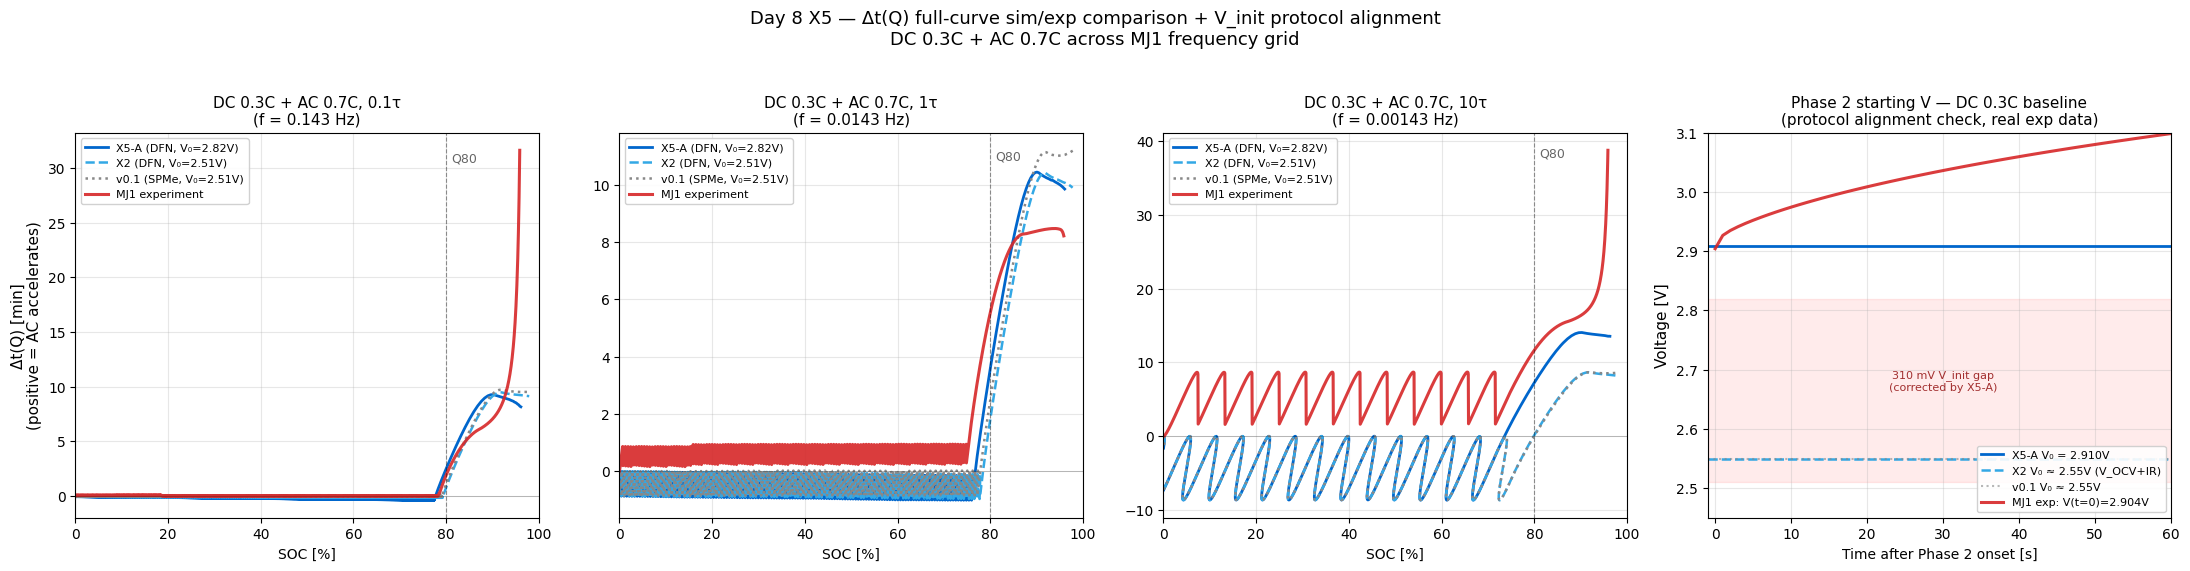


Saved: ../figures/x5_dt_Q_curves_with_V_init_check.png


In [13]:
# ============================================================
# Cell 7 v3: Δt(Q) full-curve + V(t) baseline alignment with REAL exp data
# Fixes:
#   (1) Tail clip on sim trajectories (avoid sparse-sampling artifact)
#   (2) Real DC 0.3C baseline V(t) from NGU201 in panel 4
# ============================================================
import matplotlib.pyplot as plt

# === Load all data ===
df_exp_curves = pd.read_csv("../data/delta_tq_curve_data_strict_net.csv")
EXP_NOMINAL_AH = 3.4
SIM_NOMINAL_AH = 5.126

# Load DC 0.3C baseline experimental V(t) — copy file to repo first if not there
import os
exp_baseline_paths = [
    "../data/0_3C_dc.csv",
    "../data/0.3C dc.csv",                              # ← 添加
    "/Users/louislu/DC+AC/jieguo/0.3C/NGU/0_3C_dc.csv",
    "/Users/louislu/DC+AC/jieguo/0.3C/NGU/0.3C dc.csv", # ← 添加
]
exp_baseline_df = None
for p in exp_baseline_paths:
    if os.path.exists(p):
        exp_baseline_df = pd.read_csv(p, skiprows=13)
        exp_baseline_df = exp_baseline_df.dropna(subset=["U1[V]", "I1[A]"]).reset_index(drop=True)
        exp_baseline_df["t_s"] = exp_baseline_df.index.astype(float)
        exp_baseline_df["t_min"] = exp_baseline_df["t_s"] / 60.0
        # Cumulative Q [mAh] from 1s-sampled I [A]
        exp_baseline_df["Q_mAh"] = np.cumsum(exp_baseline_df["I1[A]"].values) * 1.0 / 3.6
        print(f"Loaded experimental baseline: {p} ({len(exp_baseline_df)} samples)")
        break
if exp_baseline_df is None:
    print("⚠ Experimental DC 0.3C baseline not found — skipping panel 4 V(t) overlay")

# Trajectory clipping helper
def compute_dt_trajectory_clean(protocol_result, baseline_t, baseline_Q, q_clip_pct=98.0):
    t_p = np.array(protocol_result["t_chg"], dtype=float)
    Q_p = np.array(protocol_result["Q_net_trajectory"], dtype=float)
    t_b = np.asarray(baseline_t, dtype=float)
    Q_b = np.asarray(baseline_Q, dtype=float)
    order = np.argsort(Q_b)
    Q_b_s = Q_b[order]; t_b_s = t_b[order]
    t_b_at_Q_p = np.interp(Q_p, Q_b_s, t_b_s, left=np.nan, right=np.nan)
    dt_min = (t_b_at_Q_p - t_p) / 60.0
    Q_max_p = Q_p.max()
    Q_clip = Q_max_p * (q_clip_pct / 100.0)
    mask = Q_p <= Q_clip
    return Q_p[mask], dt_min[mask]

def find_case(results, DC, AC, f_target, tol=1e-5):
    for r in results:
        if r.get("status") != "ok": continue
        if abs(float(r["I_DC_Crate"]) - DC) > 1e-3: continue
        if abs(float(r["A_Crate"]) - AC) > 1e-3: continue
        if abs(float(r["f_Hz"]) - f_target) > tol: continue
        return r
    return None

def get_baseline(results, DC=0.3):
    for r in results:
        if abs(float(r["I_DC_Crate"]) - DC) < 1e-3 and r["A_Crate"] < 1e-9 and r.get("status") == "ok":
            return np.array(r["t_chg"], dtype=float), np.array(r["Q_net_trajectory"], dtype=float)
    return None, None

f_TARGETS = {"0.1τ": 0.143, "1τ": 0.0143, "10τ": 0.00143}

bl_x5A_t, bl_x5A_Q = get_baseline(x5A_results_loaded, 0.3)
bl_x2_t, bl_x2_Q = get_baseline(x2_results_loaded, 0.3)
bl_v01_t, bl_v01_Q = get_baseline(v01_json_loaded, 0.3)

# === Build figure ===
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

colors = {"X5-A": "#0066CC", "X2": "#33A8E5", "v0.1": "#888888", "exp": "#D62728"}
linestyles = {"X5-A": "-", "X2": "--", "v0.1": ":", "exp": "-"}

exp_protocol_map = {
    "0.1τ": "0.3+0.7 0.1tau.csv",
    "1τ":   "0.3+0.7 1tau.csv",
    "10τ":  "0.3+0.7 10 tau.csv",
}

# === Panels 1-3: Δt(Q) curves ===
for ax_idx, tau_label in enumerate(["0.1τ", "1τ", "10τ"]):
    ax = axes[ax_idx]
    f_target = f_TARGETS[tau_label]
    
    case = find_case(x5A_results_loaded, 0.3, 0.7, f_target)
    if case is not None and bl_x5A_Q is not None:
        Q_mAh, dt = compute_dt_trajectory_clean(case, bl_x5A_t, bl_x5A_Q)
        Q_pct = Q_mAh / (SIM_NOMINAL_AH * 1000) * 100
        ax.plot(Q_pct, dt, color=colors["X5-A"], linestyle=linestyles["X5-A"],
                linewidth=2, label="X5-A (DFN, V₀=2.82V)")
    
    case = find_case(x2_results_loaded, 0.3, 0.7, f_target)
    if case is not None and bl_x2_Q is not None:
        Q_mAh, dt = compute_dt_trajectory_clean(case, bl_x2_t, bl_x2_Q)
        Q_pct = Q_mAh / (SIM_NOMINAL_AH * 1000) * 100
        ax.plot(Q_pct, dt, color=colors["X2"], linestyle=linestyles["X2"],
                linewidth=1.8, label="X2 (DFN, V₀=2.51V)")
    
    case = find_case(v01_json_loaded, 0.3, 0.7, f_target)
    if case is not None and bl_v01_Q is not None:
        Q_mAh, dt = compute_dt_trajectory_clean(case, bl_v01_t, bl_v01_Q)
        Q_pct = Q_mAh / (SIM_NOMINAL_AH * 1000) * 100
        ax.plot(Q_pct, dt, color=colors["v0.1"], linestyle=linestyles["v0.1"],
                linewidth=1.8, label="v0.1 (SPMe, V₀=2.51V)")
    
    df_exp_sub = df_exp_curves[df_exp_curves["protocol"] == exp_protocol_map[tau_label]]
    Q_exp_pct = df_exp_sub["Q_net_Ah"].values / EXP_NOMINAL_AH * 100
    dt_exp = df_exp_sub["Delta_t_Q_min"].values
    ax.plot(Q_exp_pct, dt_exp, color=colors["exp"], linestyle=linestyles["exp"],
            linewidth=2.2, label="MJ1 experiment", alpha=0.9)
    
    ax.axvline(80, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 1
    ax.text(81, y_top * 0.92, 'Q80', fontsize=9, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.set_title(f"DC 0.3C + AC 0.7C, {tau_label}\n(f = {f_target} Hz)", fontsize=11)
    ax.set_xlabel("SOC [%]", fontsize=10)
    if ax_idx == 0:
        ax.set_ylabel("Δt(Q) [min]\n(positive = AC accelerates)", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.set_xlim(0, 100)

# === Panel 4: V(t) baseline first 60s — REAL data ===
ax = axes[3]

# X5-A baseline V(t): not stored in trajectory (only Q, I), so use V_init only
bl_x5A_case = next((r for r in x5A_results_loaded
                    if abs(r["I_DC_Crate"]-0.3)<1e-3 and r["A_Crate"]<1e-9 and r.get("status")=="ok"), None)
if bl_x5A_case and "V_init_phase2" in bl_x5A_case:
    ax.axhline(bl_x5A_case["V_init_phase2"], color=colors["X5-A"], linestyle="-", linewidth=2,
               label=f"X5-A V₀ = {bl_x5A_case['V_init_phase2']:.3f}V")

# X2 / v0.1 V_init estimates
ax.axhline(2.55, color=colors["X2"], linestyle="--", linewidth=1.8,
           label="X2 V₀ ≈ 2.55V (V_OCV+IR)")
ax.axhline(2.55, color=colors["v0.1"], linestyle=":", linewidth=1.5, alpha=0.6,
           label="v0.1 V₀ ≈ 2.55V")

# REAL experimental V(t) for first 60s
if exp_baseline_df is not None:
    sub = exp_baseline_df[exp_baseline_df["t_s"] <= 60]
    ax.plot(sub["t_s"], sub["U1[V]"], color=colors["exp"], linestyle=linestyles["exp"],
            linewidth=2.2, label=f"MJ1 exp: V(t=0)={sub['U1[V]'].iloc[0]:.3f}V", alpha=0.9)

ax.set_xlim(-1, 60)
ax.set_ylim(2.45, 3.10)
ax.set_xlabel("Time after Phase 2 onset [s]", fontsize=10)
ax.set_ylabel("Voltage [V]", fontsize=11)
ax.set_title("Phase 2 starting V — DC 0.3C baseline\n(protocol alignment check, real exp data)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.fill_between([-1, 60], 2.51, 2.82, color='red', alpha=0.08)
ax.text(30, 2.665, "310 mV V_init gap\n(corrected by X5-A)",
        fontsize=8, ha='center', alpha=0.8, color='darkred')

fig.suptitle("Day 8 X5 — Δt(Q) full-curve sim/exp comparison + V_init protocol alignment\n"
             "DC 0.3C + AC 0.7C across MJ1 frequency grid",
             fontsize=13, y=1.03)

plt.tight_layout()
plt.savefig("../figures/x5_dt_Q_curves_with_V_init_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: ../figures/x5_dt_Q_curves_with_V_init_check.png")